In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from auto_kernel_ensemble import KernelAutoregressiveModel
from data_loader import DataLoader
from walk_forward import WalkForwardValidator
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from metrics import ForecastingMetrics

In [2]:
# read in the data for the below ticker
ticker = 'OSK'
df_asset = pd.read_parquet(f'data/{ticker}.parquet')
df_asset.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1985-10-02,1.359799,2.791667,2.833333,2.791667,2.791667,4849200
1985-10-03,1.380093,2.833333,2.875000,2.833333,2.833333,1974000
1985-10-04,1.380093,2.833333,2.875000,2.833333,2.833333,694800
1985-10-07,1.359799,2.791667,2.833333,2.791667,2.833333,337200
1985-10-08,1.359799,2.791667,2.833333,2.791667,2.791667,436200


In [3]:
# get general stats
df_asset.describe()

,Adj Close,Close,High,Low,Open,Volume
count,10124.000000,10124.000000,10124.000000,10124.000000,10124.000000,1.012400e+04
mean,30.588337,34.785139,35.253993,34.310930,34.795508,5.592943e+05
std,33.749366,35.589878,36.029920,35.155616,35.605970,6.871637e+05
min,0.649986,1.187500,1.208333,1.125000,1.125000,0.000000e+00
25%,1.732046,2.833333,2.875000,2.791667,2.833333,1.326000e+05
50%,19.227040,23.477500,23.780001,23.155000,23.507500,4.136000e+05
75%,46.068657,55.205001,55.889999,54.542500,55.200001,7.270500e+05
max,142.852798,143.440002,144.300003,142.449997,144.300003,1.463630e+07


In [4]:
# split the dat into train and test sets
split_record = int(len(df_asset)*0.8)
df_asset_train = df_asset.iloc[:split_record]
df_asset_test = df_asset.iloc[split_record:]

# split the training into analysis and validation sets
split_record2 = int(len(df_asset_train)*0.8)
df_asset_train_analysis = df_asset_train.iloc[:split_record2]
df_asset_train_validation = df_asset_train.iloc[split_record2:]
print (
    f'Train set size: {len(df_asset_train)}\n'
    f'Test set size: {len(df_asset_test)}\n'
    f'Train set analysis size: {len(df_asset_train_analysis)}\n'
    f'Train set validation size: {len(df_asset_train_validation)}'
)

Train set size: 8099
Test set size: 2025
Train set analysis size: 6479
Train set validation size: 1620


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1231598919.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1231598919.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close'].rolling(window=60).mean()


<Axes: xlabel='Date'>

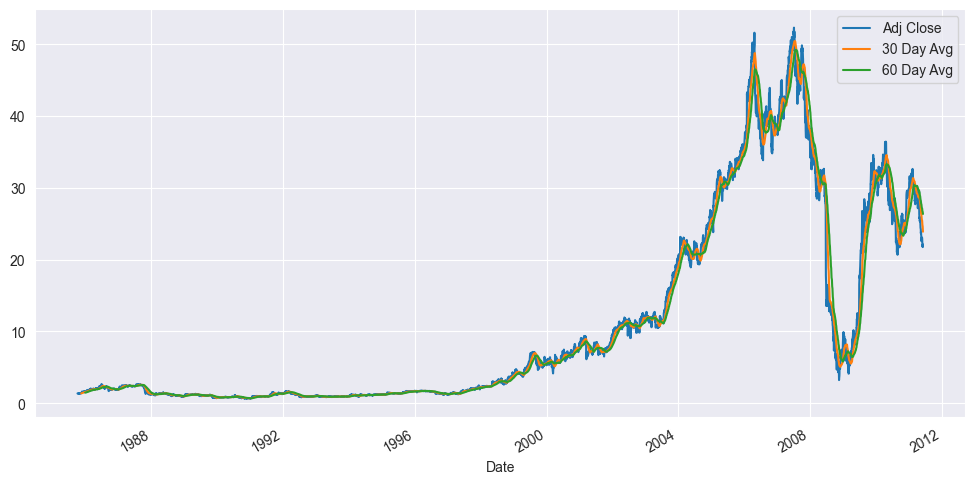

In [5]:
# plot the asset price. There should be the actual, the 30 day moving average, and the 60 day moving avg
df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close'].rolling(window=30).mean()
df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close'].rolling(window=60).mean()
df_asset_train_analysis[['Adj Close', '30 Day Avg', '60 Day Avg']].plot(figsize=(12, 6))

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/3662363008.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['Running Mean'] = mean_vals
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/3662363008.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['Running Median'] = meadian_vals


<Axes: xlabel='Date'>

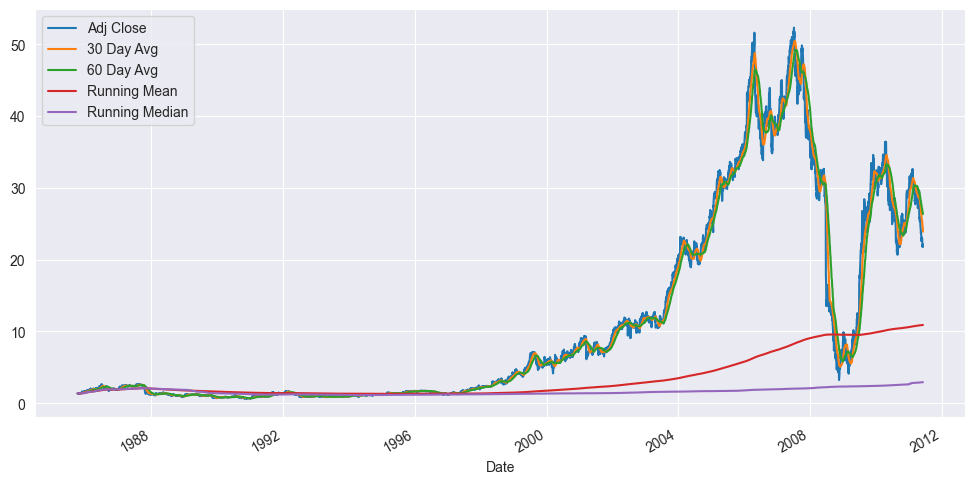

In [6]:
# calculate the running mean and median of the adj close price using a growing window
ending_index = 0
growing_window = [(0, x) for x in range(df_asset_train_analysis.shape[0]) if x >= ending_index]
meadian_vals = []
mean_vals = []
for window in growing_window:
    mean_vals.append(df_asset_train_analysis['Adj Close'][window[0]:window[1]].mean())
    meadian_vals.append(df_asset_train_analysis['Adj Close'][window[0]:window[1]].median())

# add a a column
df_asset_train_analysis['Running Mean'] = mean_vals
df_asset_train_analysis['Running Median'] = meadian_vals
df_asset_train_analysis[['Adj Close', '30 Day Avg', '60 Day Avg', 'Running Mean', 'Running Median']].plot(figsize=(12, 6))

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/3225785681.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['Adj Close Normalized'] = scaler.fit_transform(df_asset_train_analysis[['Adj Close']])


<Axes: xlabel='Date'>

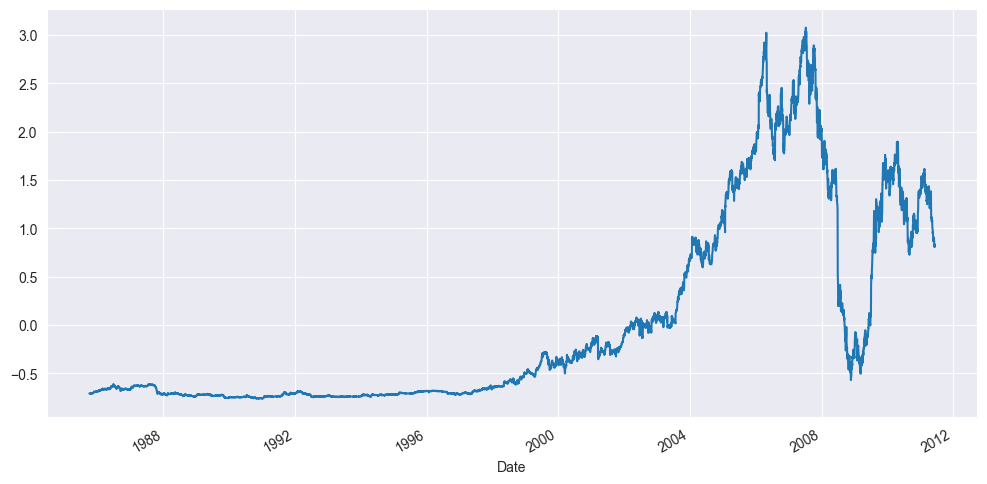

In [7]:
# standardarize the Adj close price then plot the running mean  of the normalized values
scaler = StandardScaler()
df_asset_train_analysis['Adj Close Normalized'] = scaler.fit_transform(df_asset_train_analysis[['Adj Close']])
df_asset_train_analysis['Adj Close Normalized'].plot(figsize=(12, 6))

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/126024567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/126024567.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=60).mean()
/var/folders/h3/n4kr77l914l79r

<Axes: xlabel='Date'>

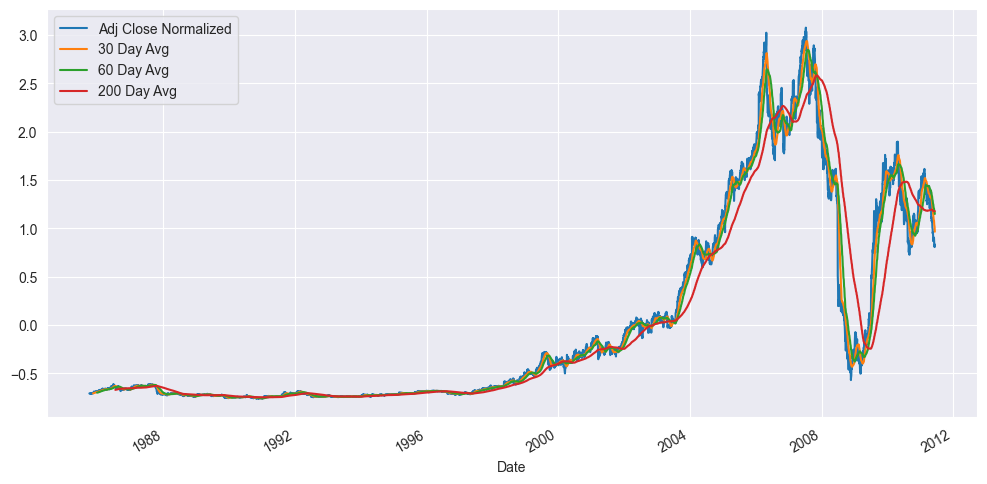

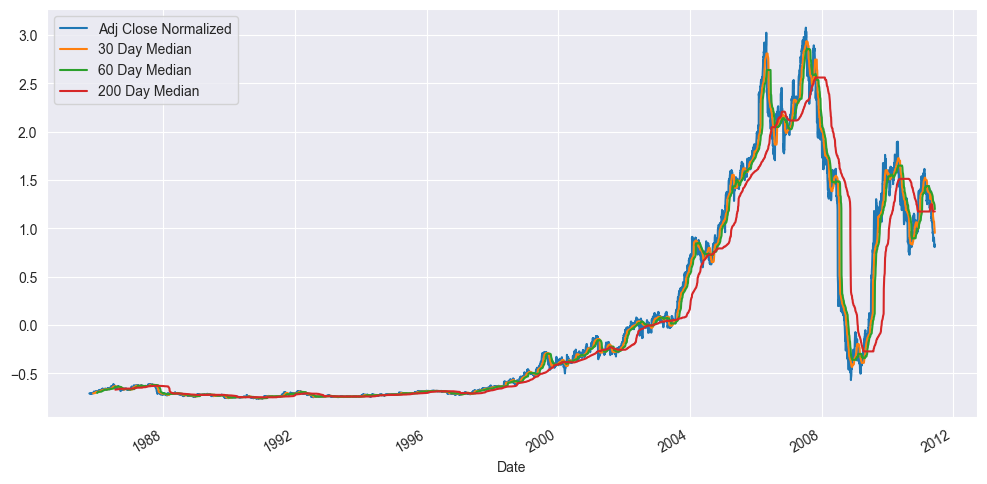

In [8]:
# smooth the values
df_asset_train_analysis['30 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=30).mean()
df_asset_train_analysis['60 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=60).mean()
df_asset_train_analysis['200 Day Avg'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=200).mean()

df_asset_train_analysis['30 Day Median'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=30).median()
df_asset_train_analysis['60 Day Median'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=60).median()
df_asset_train_analysis['200 Day Median'] = df_asset_train_analysis['Adj Close Normalized'].rolling(window=200).median()

mean_columns = ['Adj Close Normalized', '30 Day Avg', '60 Day Avg', '200 Day Avg']
median_columns = ['Adj Close Normalized', '30 Day Median', '60 Day Median', '200 Day Median']
df_asset_train_analysis[mean_columns].plot(figsize=(12, 6))
df_asset_train_analysis[median_columns].plot(figsize=(12, 6))

In [9]:
# Remove NaN values from 30 Day Avg for autocorrelation analysis
df_asset_train_analysis['30 Day Avg Diff'] = df_asset_train_analysis['30 Day Avg'].diff()
df_asset_train_analysis[['30 Day Avg', '30 Day Avg Diff']].tail(15)

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/4010599652.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train_analysis['30 Day Avg Diff'] = df_asset_train_analysis['30 Day Avg'].diff()


,30 Day Avg,30 Day Avg Diff
Date,,
2011-05-19,1.167653,-0.014776
2011-05-20,1.153289,-0.014364
2011-05-23,1.138781,-0.014508
2011-05-24,1.125116,-0.013664
2011-05-25,1.113325,-0.011792
2011-05-26,1.102007,-0.011318
2011-05-27,1.091573,-0.010433
2011-05-31,1.079349,-0.012224
2011-06-01,1.066261,-0.013088


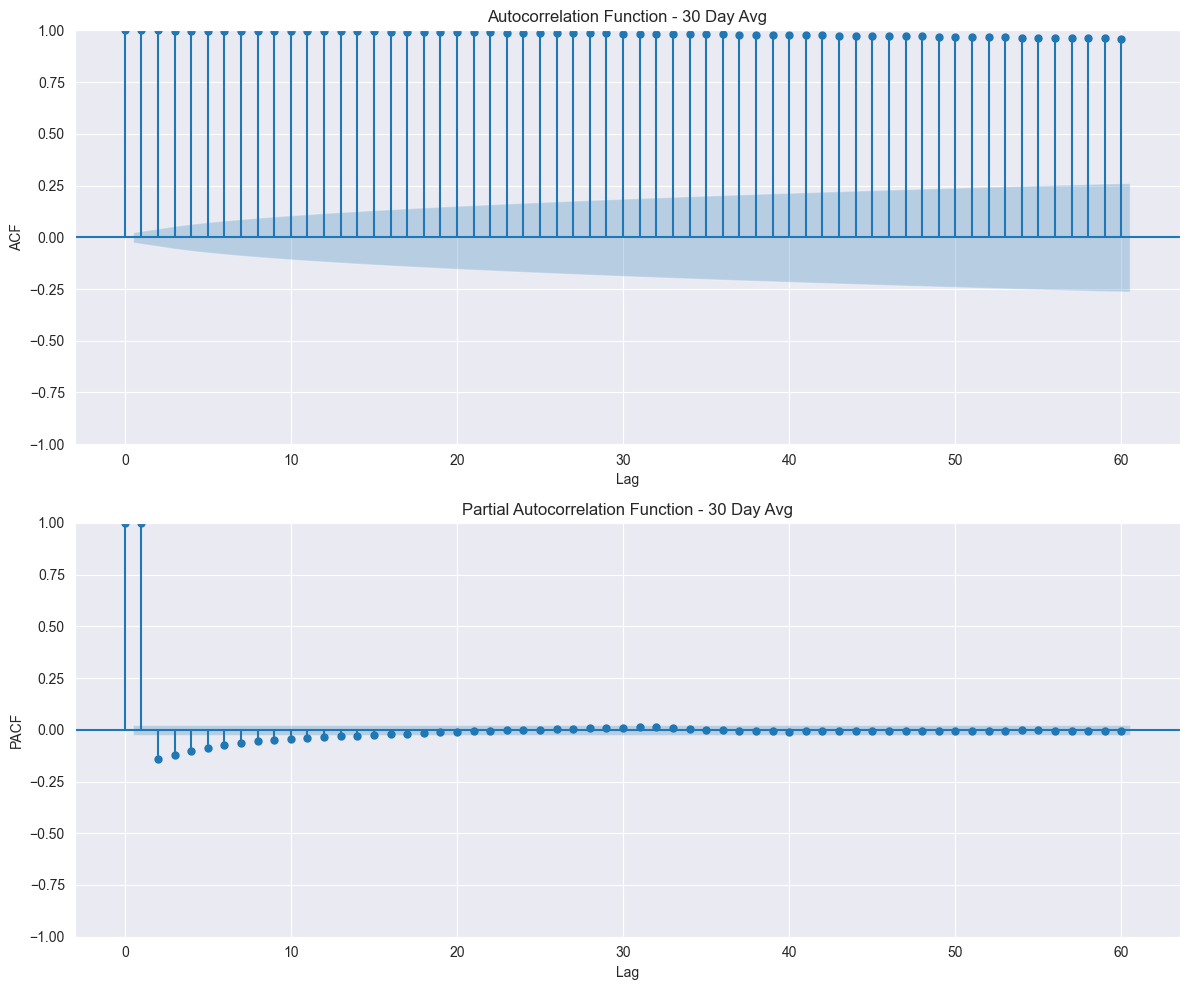

In [10]:
data_30_day = df_asset_train_analysis['30 Day Avg'].dropna()

# Create subplots for ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot Autocorrelation Function (ACF) with 30 lags
plot_acf(data_30_day, lags=60, ax=ax1, title='Autocorrelation Function - 30 Day Avg')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')

# Plot Partial Autocorrelation Function (PACF) with 30 lags
plot_pacf(data_30_day, lags=60, ax=ax2, title='Partial Autocorrelation Function - 30 Day Avg')
ax2.set_xlabel('Lag')
ax2.set_ylabel('PACF')

plt.tight_layout()
plt.show()

<Axes: xlabel='Date'>

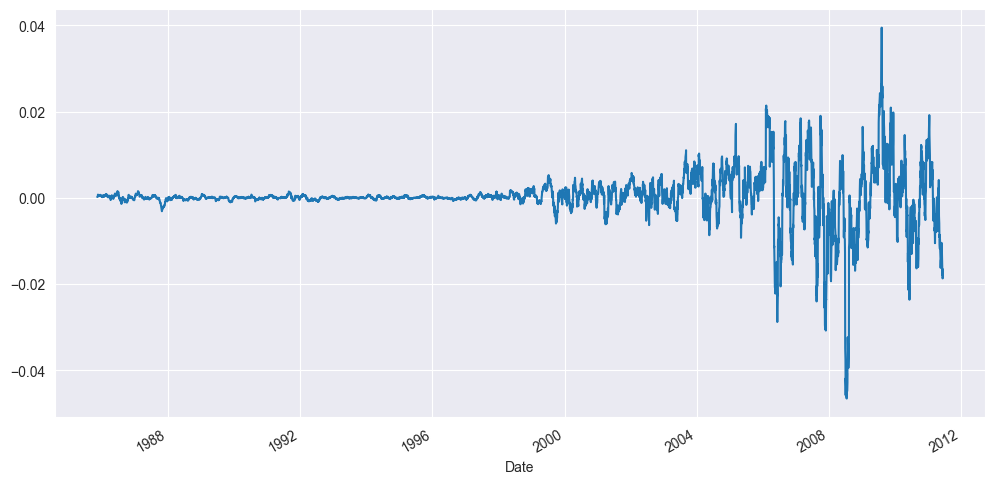

In [11]:
# plot the differencing
df_asset_train_analysis['30 Day Avg Diff'].plot(figsize=(12, 6))

In [13]:
# create the lag variables up to 15 days
lag_value = 30
for lag in range(lag_value):
    lag_val = lag + 1
    df_asset_train_analysis[f'Lag {lag_val}'] = df_asset_train_analysis['30 Day Avg'].shift(lag_val)
df_asset_train_analysis = df_asset_train_analysis.dropna()
df_asset_train_analysis.head()

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,60 Day Avg,Running Mean,Running Median,...,Lag 21,Lag 22,Lag 23,Lag 24,Lag 25,Lag 26,Lag 27,Lag 28,Lag 29,Lag 30
Date,,,,,,,,,,,,,,,,,,,,,
1986-08-28,2.232504,4.583333,4.666667,4.541667,4.625000,121800,-0.645085,-0.638211,1.902813,1.928071,...,-0.634705,-0.634102,-0.633549,-0.632795,-0.632443,-0.632141,-0.632141,-0.631940,-0.631639,-0.631337
1986-08-29,2.212209,4.541667,4.625000,4.541667,4.583333,63600,-0.645186,-0.638412,1.904247,1.928071,...,-0.635208,-0.634705,-0.634102,-0.633549,-0.632795,-0.632443,-0.632141,-0.632141,-0.631940,-0.631639
1986-09-02,2.131028,4.375000,4.583333,4.375000,4.541667,67200,-0.645538,-0.638739,1.905580,1.928071,...,-0.635886,-0.635208,-0.634705,-0.634102,-0.633549,-0.632795,-0.632443,-0.632141,-0.632141,-0.631940
1986-09-03,2.110732,4.333333,4.416667,4.250000,4.375000,166200,-0.645940,-0.639041,1.906552,1.928071,...,-0.636666,-0.635886,-0.635208,-0.634705,-0.634102,-0.633549,-0.632795,-0.632443,-0.632141,-0.632141
1986-09-04,2.151323,4.416667,4.416667,4.333333,4.333333,164400,-0.646242,-0.639192,1.907428,1.928071,...,-0.637319,-0.636666,-0.635886,-0.635208,-0.634705,-0.634102,-0.633549,-0.632795,-0.632443,-0.632141


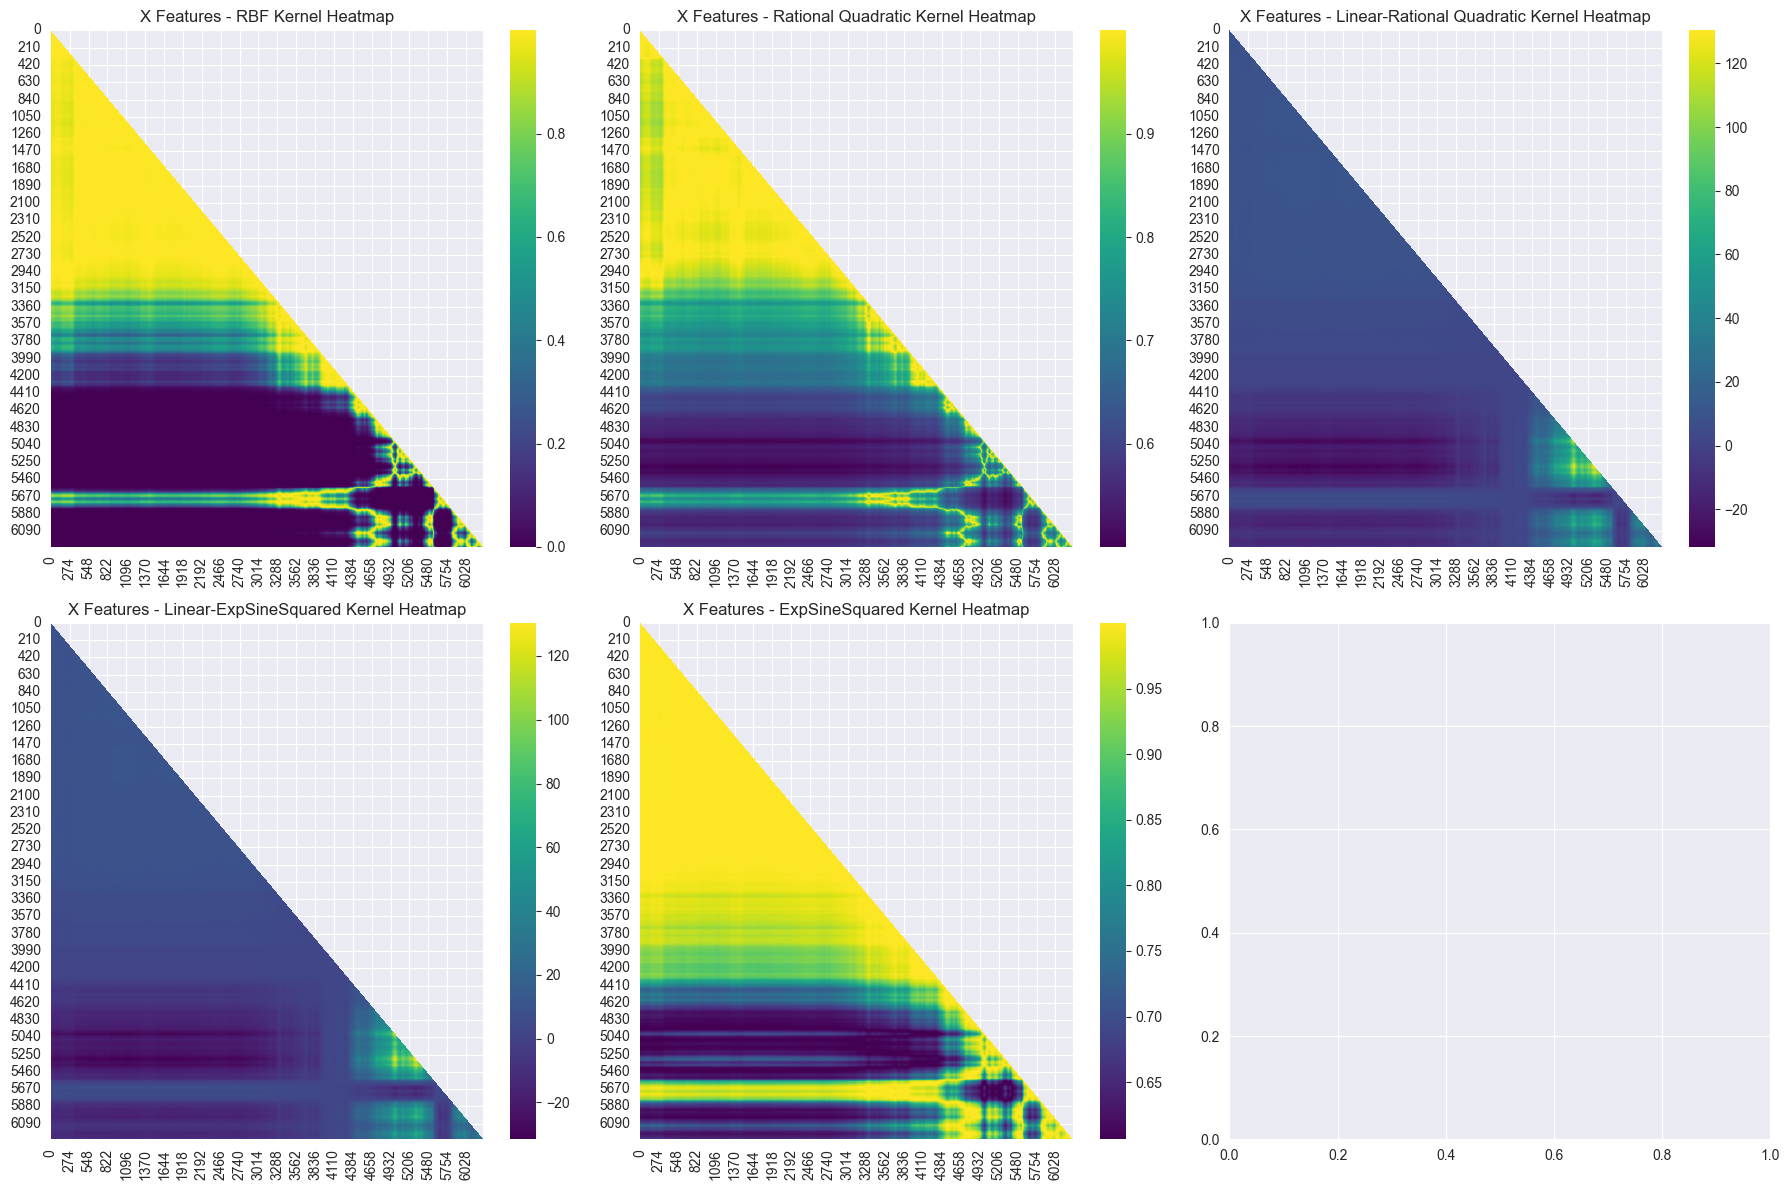

In [16]:
independent_variable = [x for x in df_asset_train_analysis.columns if 'Lag' in x]
target_variable = '30 Day Avg Diff'

kernel_test = (ConstantKernel(1.0, (1e-3, 1e3)) *
               # DotProduct() *
               RBF(length_scale=1.5, length_scale_bounds=(1e-7, 1e7)) +
               WhiteKernel(noise_level=1e-5))

kernel_test2 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                # DotProduct() *
                RationalQuadratic(length_scale=1.0, alpha=0.1,
                                  length_scale_bounds=(1e-5, 1e5),
                                  alpha_bounds=(1e-5, 1e5)) +
                WhiteKernel(noise_level=1e-5))

kernel_test3 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                DotProduct() +
                RationalQuadratic(length_scale=1.0, alpha=0.1,
                                  length_scale_bounds=(1e-5, 1e5),
                                  alpha_bounds=(1e-5, 1e5)) +
                WhiteKernel(noise_level=1e-5))

kernel_test4 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                DotProduct() +
                ExpSineSquared(length_scale=2, periodicity=20.0,
                               length_scale_bounds=(0.01, 10),
                               periodicity_bounds=(1e-2, 1e2)) +
                WhiteKernel(noise_level=1e-5))

kernel_test5 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                # DotProduct() *
                ExpSineSquared(length_scale=2, periodicity=20.0,
                               length_scale_bounds=(0.01, 10),
                               periodicity_bounds=(1e-2, 1e2)) +
                WhiteKernel(noise_level=1e-5))

plot_variables = [
    [kernel_test, 'RBF'],
    [kernel_test2, 'Rational Quadratic'],
    [kernel_test3, 'Linear-Rational Quadratic'],
    [kernel_test4, 'Linear-ExpSineSquared'],
    [kernel_test5, 'ExpSineSquared'],

]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, plot in enumerate(plot_variables):
    x_features = df_asset_train_analysis[independent_variable].to_numpy()
    xcov = plot[0](x_features, x_features)
    sns.heatmap(xcov, cmap='viridis', mask=np.triu(np.ones_like(xcov, dtype=bool)), cbar=True, ax=axes[i])
    axes[i].set_title(f"X Features - {plot[1]} Kernel Heatmap")

plt.tight_layout()
plt.show()

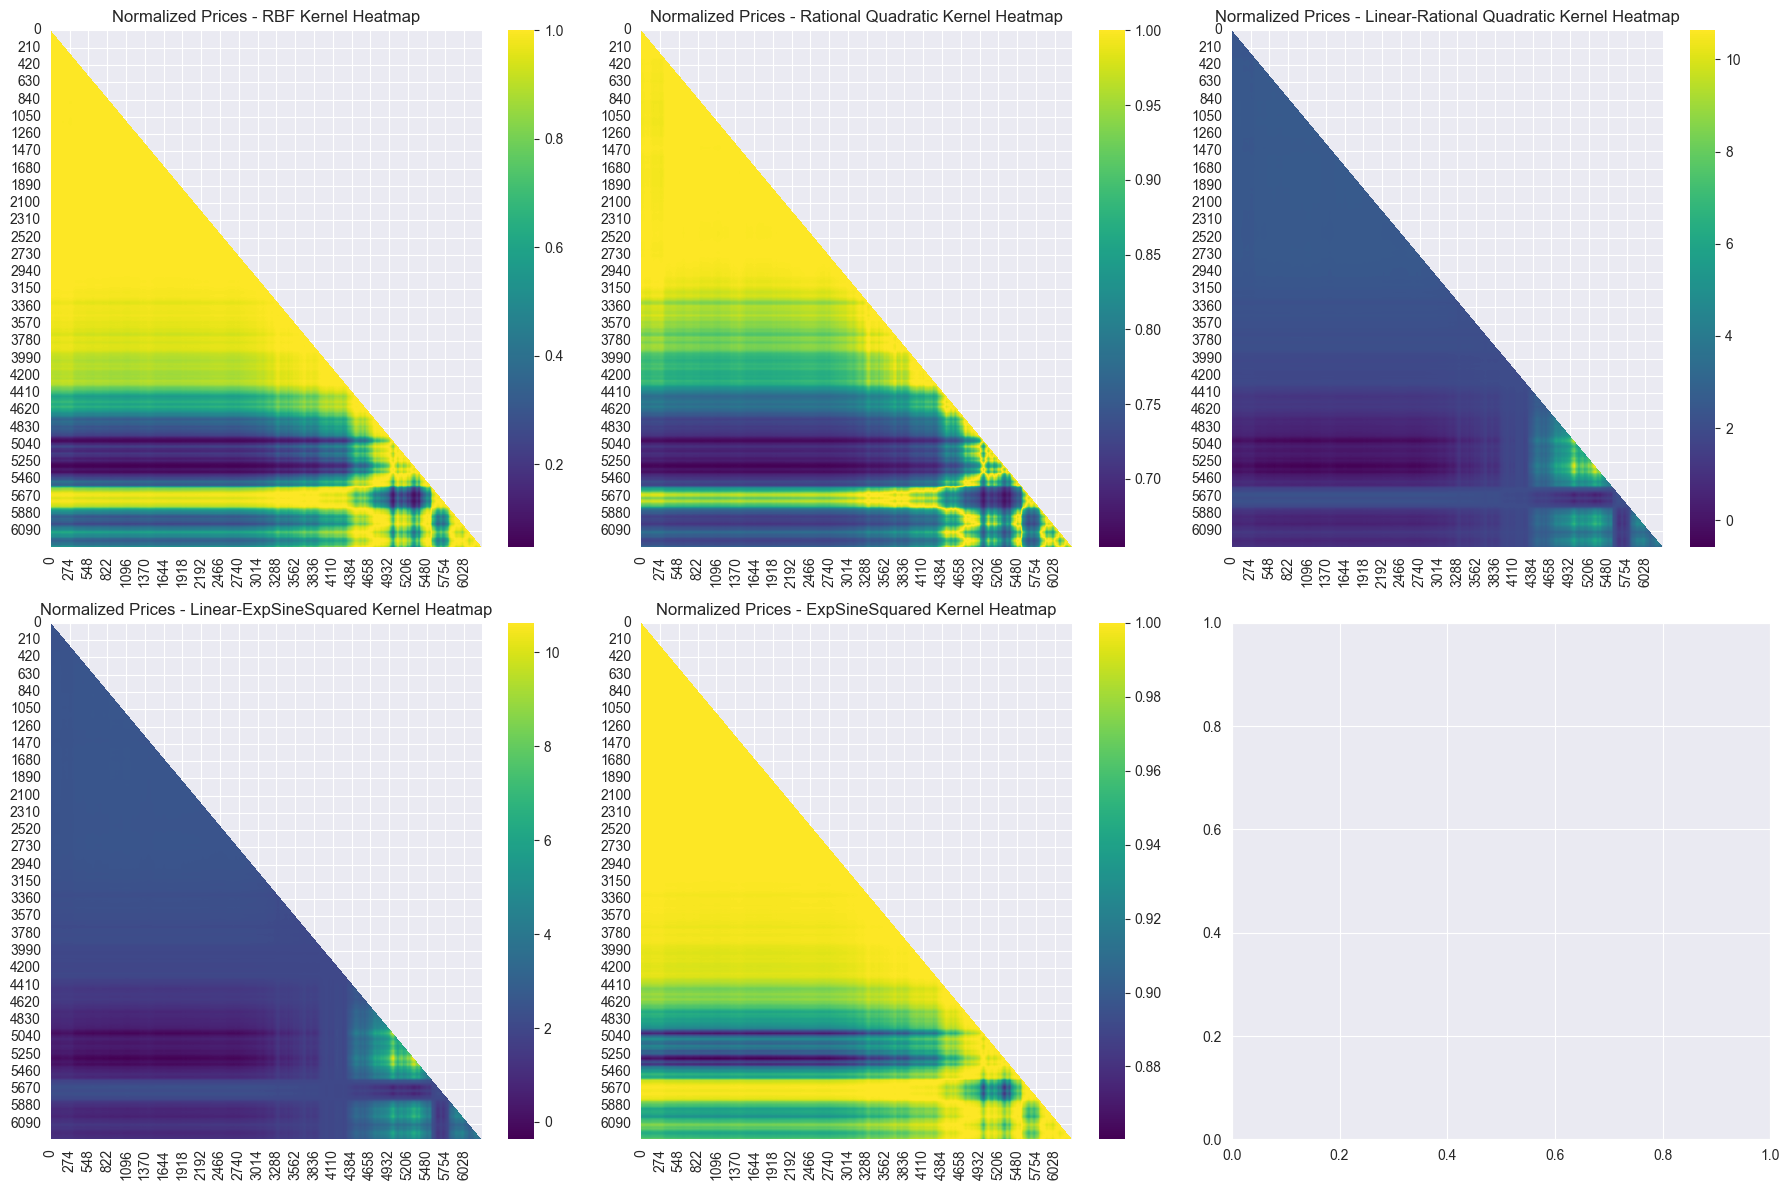

In [17]:
target_variable = '30 Day Avg'
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, plot in enumerate(plot_variables):
    y_features = df_asset_train_analysis[target_variable].to_numpy().reshape(-1, 1)
    xcov = plot[0](y_features, y_features)
    sns.heatmap(xcov, cmap='viridis', mask=np.triu(np.ones_like(xcov, dtype=bool)), cbar=True, ax=axes[i])
    axes[i].set_title(f"Normalized Prices - {plot[1]} Kernel Heatmap")

plt.tight_layout()
plt.show()

In [14]:
# create the raw dataset to get the predictor and target variables
# read in the data for the below ticker
ticker = 'OSK'
df_asset = pd.read_parquet(f'data/{ticker}.parquet')
split_record = int(len(df_asset)*0.8)
df_asset_train = df_asset.iloc[:split_record]
df_asset_test = df_asset.iloc[split_record:]

# create the 30 day moving average target variable and the 15 lag feature variables
df_asset_train['30 Day Avg'] = df_asset_train['Adj Close'].rolling(window=30).mean()
df_asset_train['30 Day Avg future value'] = df_asset_train['30 Day Avg'].shift(-13)
lag_value = 30
for lag in range(lag_value):
    lag_val = lag + 1
    df_asset_train[f'Lag {lag_val}'] = df_asset_train['30 Day Avg'].shift(lag_val)
df_asset_train = df_asset_train.dropna()
df_asset_train.to_parquet("data/osk2_train.parquet")
print(df_asset_train.shape)
df_asset_train.head()

(8027, 38)


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1387397983.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train['30 Day Avg'] = df_asset_train['Adj Close'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1387397983.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_train['30 Day Avg future value'] = df_asset_train['30 Day Avg'].shift(-13)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1387397983.py:15: Se

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,30 Day Avg future value,Lag 1,Lag 2,...,Lag 21,Lag 22,Lag 23,Lag 24,Lag 25,Lag 26,Lag 27,Lag 28,Lag 29,Lag 30
Date,,,,,,,,,,,,,,,,,,,,,
1985-12-26,1.603344,3.291667,3.291667,3.250000,3.250000,117600,1.570871,1.627360,1.564106,1.558694,...,1.421023,1.412905,1.403433,1.393286,1.386521,1.381108,1.377726,1.375020,1.372314,1.369608
1985-12-27,1.603344,3.291667,3.291667,3.250000,3.291667,96600,1.576283,1.635479,1.570871,1.564106,...,1.427112,1.421023,1.412905,1.403433,1.393286,1.386521,1.381108,1.377726,1.375020,1.372314
1985-12-30,1.583049,3.250000,3.291667,3.250000,3.291667,23400,1.580343,1.643597,1.576283,1.570871,...,1.432524,1.427112,1.421023,1.412905,1.403433,1.393286,1.386521,1.381108,1.377726,1.375020
1985-12-31,1.583049,3.250000,3.291667,3.208333,3.250000,137400,1.584402,1.650362,1.580343,1.576283,...,1.438951,1.432524,1.427112,1.421023,1.412905,1.403433,1.393286,1.386521,1.381108,1.377726
1986-01-02,1.572901,3.229167,3.250000,3.208333,3.250000,155400,1.588123,1.654759,1.584402,1.580343,...,1.445716,1.438951,1.432524,1.427112,1.421023,1.412905,1.403433,1.393286,1.386521,1.381108


In [15]:
data_load = DataLoader(data_path='data/osk2_train.parquet')
auto_kernel = KernelAutoregressiveModel(forecast_horizon=14, n_jobs=2)

independent_variables = [f'Lag {x + 1}' for x in range(30)]
data_load.load_data(x=independent_variables, y=['30 Day Avg'], actuals=['30 Day Avg future value'])
walks = WalkForwardValidator(
    model=auto_kernel,
    data_loader=data_load,
    ticker='OSK',
    lags=30,
    # forecast_horizon=5,
    # n_jobs=2,
    window_size=2000,
    min_window_size=2000,
    n_parallel_jobs=2,
    use_scaling=True,
    window_type='sliding'
)
walks.run_walk_forward_validation(target_variable='30 Day Avg')

INFO:auto_kernel_ensemble:Created 5 kernel configurations
INFO:data_loader:Loading data from data/osk2_train.parquet
INFO:data_loader:Loaded data: 8027 rows, 32 columns
INFO:data_loader:Date range: 1985-12-26 00:00:00 to 2017-10-26 00:00:00
INFO:walk_forward:Initialized walk-forward validator: window_size=2000, min_window_size=2000, step_size=1
INFO:walk_forward:Starting walk-forward validation for OSK
INFO:data_loader:Generated 6027 sliding time windows
INFO:walk_forward:Running 6027 predictions with 30 features
Running Walk Forward Validation: 100%|██████████| 6027/6027 [4:44:05<00:00,  2.83s/it]  


In [16]:
results_df = pd.DataFrame(walks.results_list)
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain
0,1993-11-22,[[0.9420416315396627]],[0.9623069501618319],Sum,None,True
1,1993-11-23,[[0.9428787926832835]],[0.961496250636295],Sum,None,False
2,1993-11-24,[[0.9445874909559886]],[0.9600120133701309],Sum,None,False
3,1993-11-26,[[0.9450060586134593]],[0.9646931980911834],Sum,None,False
4,1993-11-29,[[0.9458432197570801]],[0.9599238331740908],Sum,None,False


In [17]:
# save the results
results_df.to_parquet("data/OSK2_walk_forward_results.parquet")

In [18]:
results_df = pd.read_parquet("data/OSK2_walk_forward_results.parquet")
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain
0,1993-11-22,[[0.9420416315396627]],[0.9623069501618319],Sum,None,True
1,1993-11-23,[[0.9428787926832835]],[0.961496250636295],Sum,None,False
2,1993-11-24,[[0.9445874909559886]],[0.9600120133701309],Sum,None,False
3,1993-11-26,[[0.9450060586134593]],[0.9646931980911834],Sum,None,False
4,1993-11-29,[[0.9458432197570801]],[0.9599238331740908],Sum,None,False


In [19]:
results_df['actual'] = results_df['actual_value'].apply(lambda x: x[0][0])
results_df['predicted'] = results_df['prediction'].apply(lambda x: x[0])
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted
0,1993-11-22,[[0.9420416315396627]],[0.9623069501618319],Sum,None,True,0.942042,0.962307
1,1993-11-23,[[0.9428787926832835]],[0.961496250636295],Sum,None,False,0.942879,0.961496
2,1993-11-24,[[0.9445874909559886]],[0.9600120133701309],Sum,None,False,0.944587,0.960012
3,1993-11-26,[[0.9450060586134593]],[0.9646931980911834],Sum,None,False,0.945006,0.964693
4,1993-11-29,[[0.9458432197570801]],[0.9599238331740908],Sum,None,False,0.945843,0.959924


<Axes: >

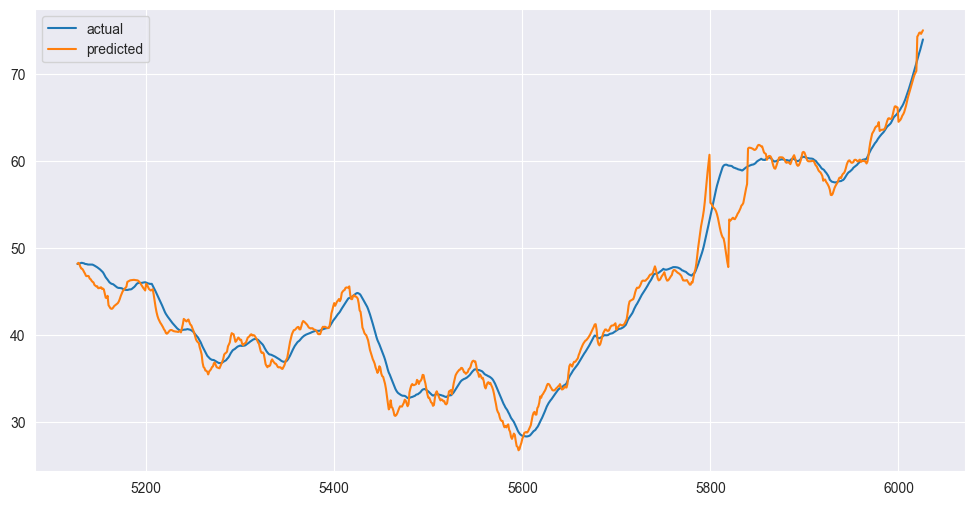

In [23]:
results_df.iloc[-900:][['actual', 'predicted']].plot(figsize=(12, 6))

In [24]:
# calculate teh regression metrics
mse = mean_squared_error(results_df['actual'], results_df['predicted'])
mae = mean_absolute_error(results_df['actual'], results_df['predicted'])
r2 = r2_score(results_df['actual'], results_df['predicted'])
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

MSE: 78.17619340238872, MAE: 1.4130069953735513, R2: 0.7305042756800822


0.06557729997594736
-0.006641502917156473
-0.010607376539709133


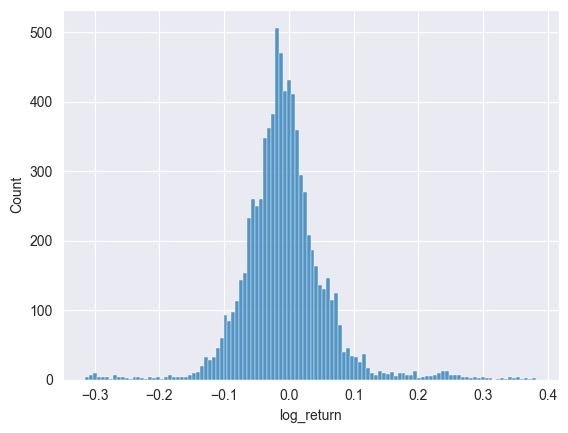

In [26]:
# calculate the 7-day log return and plot the distribution
training_data = pd.read_parquet('data/OSK2_train.parquet')
training_data['log_return'] = np.log(training_data['30 Day Avg'].shift(1) / training_data['30 Day Avg'].shift(-13))
training_data[['30 Day Avg', 'log_return']].head(100)
sns.histplot(training_data['log_return'])
print(training_data['log_return'].std())
print(training_data['log_return'].mean())
print(training_data['log_return'].median())

In [32]:
metrics = ForecastingMetrics(ticker='OSK', actuals_file='data/OSK_train.parquet')

INFO:metrics:            Adj Close     Close      High       Low      Open  Volume  \
Date                                                                    
1985-12-04   1.583049  3.250000  3.291667  3.208333  3.250000  311400   
1985-12-05   1.603344  3.291667  3.291667  3.208333  3.250000  154800   
1985-12-06   1.593197  3.270833  3.291667  3.208333  3.291667  112800   
1985-12-09   1.593197  3.270833  3.291667  3.229167  3.270833   48600   
1985-12-10   1.583049  3.250000  3.291667  3.250000  3.270833   35400   

            30 Day Avg  30 Day Avg future value     Lag 1     Lag 2  ...  \
Date                                                                 ...   
1985-12-04    1.459923                 1.504234  1.452481  1.445716  ...   
1985-12-05    1.466688                 1.511676  1.459923  1.452481  ...   
1985-12-06    1.474468                 1.521147  1.466688  1.459923  ...   
1985-12-09    1.482248                 1.528251  1.474468  1.466688  ...   
1985-12-10    1.489

INFO:root:        date  30 Day Avg_sample_0_mean  30 Day Avg_sample_0_std  \
0 2017-08-08                 61.466133                 0.423626   
1 2003-07-25                 11.553020                 0.073966   
2 2011-02-18                 31.683387                 0.365954   
3 1999-02-04                  4.509543                 0.020458   
4 1996-09-10                  1.420742                 0.011041   

   30 Day Avg_sample_0_min  30 Day Avg_sample_0_max  30 Day Avg_sample_0_97_5  \
0                59.996317                62.935470                 62.416148   
1                11.315743                11.779155                 11.703144   
2                30.396504                32.812060                 32.415581   
3                 4.454108                 4.574288                  4.551382   
4                 1.386748                 1.457514                  1.439071   

   30 Day Avg_sample_0_2_5  Adj Close      Close       High  ...      Lag 8  \
0                60.1

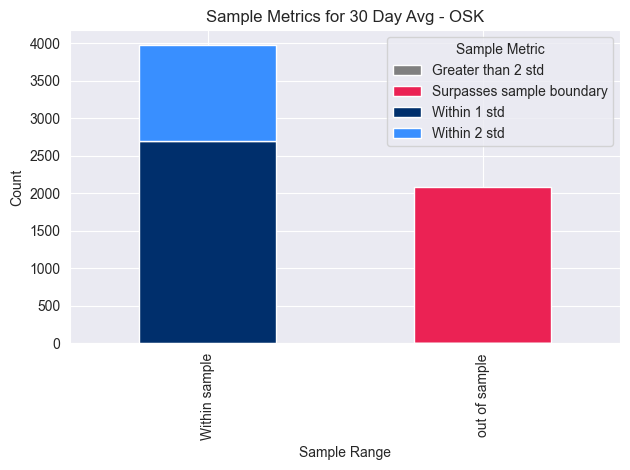

In [33]:
metrics.calculate_sample_metrics()
metrics.plot_sample_metrics()

In [28]:
# save the test data with the some of the training data to use as modeling training data
ticker = 'OSK'
df_asset = pd.read_parquet(f'data/{ticker}.parquet')
split_record = int(len(df_asset)*0.8)
df_asset_train = df_asset.iloc[:split_record]
split_record = split_record - 2040

df_asset_test = df_asset.iloc[split_record:]

# create the 30 day moving average target variable and the 15 lag feature variables
df_asset_test['30 Day Avg'] = df_asset_test['Adj Close'].rolling(window=30).mean()
df_asset_test['30 Day Avg future value'] = df_asset_test['30 Day Avg'].shift(-13)
lag_value = 30
for lag in range(lag_value):
    lag_val = lag + 1
    df_asset_test[f'Lag {lag_val}'] = df_asset_test['30 Day Avg'].shift(lag_val)
df_asset_test = df_asset_test.dropna()
df_asset_test.to_parquet("data/OSK2_test.parquet")
print(df_asset_test.shape)
df_asset_test.head()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1720824175.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_test['30 Day Avg'] = df_asset_test['Adj Close'].rolling(window=30).mean()
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1720824175.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asset_test['30 Day Avg future value'] = df_asset_test['30 Day Avg'].shift(-13)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_76803/1720824175.py:16: Settin

(3993, 38)


,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,30 Day Avg future value,Lag 1,Lag 2,...,Lag 21,Lag 22,Lag 23,Lag 24,Lag 25,Lag 26,Lag 27,Lag 28,Lag 29,Lag 30
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,32.295448,38.869999,39.110001,37.950001,38.599998,1715100,31.984985,31.271278,31.993016,32.043699,...,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240,29.611224,29.507921,29.386616
2010-01-06,31.946491,38.450001,38.919998,38.279999,38.730000,781600,31.998278,31.136402,31.984985,31.993016,...,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240,29.611224,29.507921
2010-01-07,32.453323,39.060001,39.130001,37.880001,38.490002,884400,32.042038,30.998756,31.998278,31.984985,...,31.028669,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240,29.611224
2010-01-08,32.129272,38.669998,39.410000,38.439999,38.889999,944500,32.049238,31.011219,32.042038,31.998278,...,31.208135,31.028669,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240
2010-01-11,31.954796,38.459999,38.900002,38.080002,38.849998,827200,32.032067,31.006788,32.049238,32.042038,...,31.434405,31.208135,31.028669,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701


In [29]:
data_load = DataLoader(data_path='data/OSK2_test.parquet')
auto_kernel = KernelAutoregressiveModel(forecast_horizon=14, n_jobs=2)

independent_variables = [f'Lag {x + 1}' for x in range(30)]
data_load.load_data(x=independent_variables, y=['30 Day Avg'], actuals=['30 Day Avg future value'])
walks = WalkForwardValidator(
    model=auto_kernel,
    data_loader=data_load,
    ticker='OSK',
    lags=30,
    # forecast_horizon=5,
    # n_jobs=2,
    window_size=2000,
    min_window_size=2000,
    n_parallel_jobs=2,
    use_scaling=True,
    window_type='sliding'
)
walks.run_walk_forward_validation(target_variable='30 Day Avg')

INFO:auto_kernel_ensemble:Created 5 kernel configurations
INFO:data_loader:Loading data from data/OSK2_test.parquet
INFO:data_loader:Loaded data: 3993 rows, 32 columns
INFO:data_loader:Date range: 2010-01-05 00:00:00 to 2025-11-17 00:00:00
INFO:walk_forward:Initialized walk-forward validator: window_size=2000, min_window_size=2000, step_size=1
INFO:walk_forward:Starting walk-forward validation for OSK
INFO:data_loader:Generated 1993 sliding time windows
INFO:walk_forward:Running 1993 predictions with 30 features
Running Walk Forward Validation: 100%|██████████| 1993/1993 [1:33:31<00:00,  2.82s/it]  


In [30]:
results_df = pd.DataFrame(walks.results_list)
results_df.to_parquet("data/OSK2_test_walk_forward_results.parquet")

<Axes: >

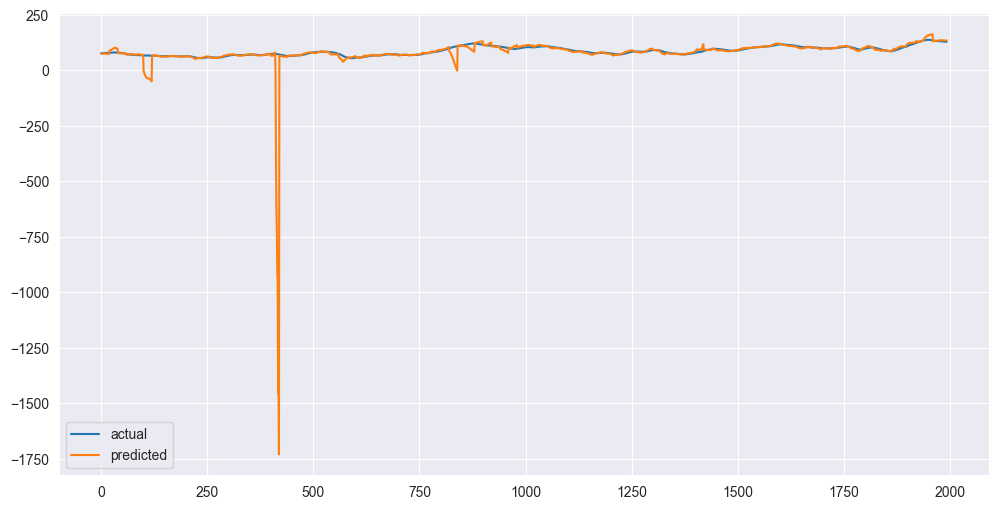

In [31]:
results_df['actual'] = results_df['actual_value'].apply(lambda x: x[0][0])
results_df['predicted'] = results_df['prediction'].apply(lambda x: x[0])
results_df[['actual', 'predicted']].plot(figsize=(12, 6))

In [38]:
# calculate teh regression metrics
mse = mean_squared_error(results_df['actual'], results_df['predicted'])
mae = mean_absolute_error(results_df['actual'], results_df['predicted'])
r2 = r2_score(results_df['actual'], results_df['predicted'])
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

MSE: 2.9060777426253916, MAE: 1.346648252293177, R2: 0.9921827397513887


In [39]:
# What is the risk when guessing wrong
results_df = pd.read_parquet("data/OSK_test_walk_forward_results.parquet")
results_df['actual'] = results_df['actual_value'].apply(lambda x: x[0][0])
results_df['predicted'] = results_df['prediction'].apply(lambda x: x[0])
results_df.head()

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted
0,2017-11-21,[[76.66347147623698]],[76.29254249049694],Sum,None,True,76.663471,76.292542
1,2017-11-22,[[76.68080062866211]],[76.39692639795726],Sum,None,False,76.680801,76.396926
2,2017-11-24,[[76.66004384358725]],[76.33427544879379],Sum,None,False,76.660044,76.334275
3,2017-11-27,[[76.62926610310872]],[76.18238001134645],Sum,None,False,76.629266,76.182380
4,2017-11-28,[[76.62649129231771]],[76.08787056529701],Sum,None,False,76.626491,76.087871


In [40]:
actual_results = pd.read_parquet('data/OSK_test.parquet')
actual_results['date'] = actual_results.index
actual_results['log_return'] = np.log(actual_results['Adj Close'].shift(-6) / actual_results['Adj Close'].shift(1))
actual_results.head(15)

,Adj Close,Close,High,Low,Open,Volume,30 Day Avg,30 Day Avg future value,Lag 1,Lag 2,...,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15,date,log_return
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-11,34.031933,40.959999,41.570000,39.959999,40.490002,1347700,31.955906,32.319821,31.700834,31.434405,...,30.396109,30.217197,30.026100,29.898701,29.755240,29.611224,29.507921,29.386616,2009-12-11,NaN
2009-12-14,30.176750,36.320000,41.419998,33.000000,41.419998,14099300,32.096044,32.314005,31.955906,31.700834,...,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240,29.611224,29.507921,2009-12-14,-0.079229
2009-12-15,30.101980,36.230000,36.840000,34.230000,35.290001,3663500,32.217903,32.269414,32.096044,31.955906,...,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240,29.611224,2009-12-15,0.029302
2009-12-16,29.894270,35.980000,36.730000,35.360001,36.410000,1687100,32.237013,32.213746,32.217903,32.096044,...,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,29.755240,2009-12-16,0.053995
2009-12-17,30.808220,37.080002,38.700001,35.490002,35.490002,4018600,32.274678,32.188821,32.237013,32.217903,...,31.028669,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,29.898701,2009-12-17,0.069512
2009-12-18,31.140545,37.480000,38.360001,37.250000,37.709999,2366700,32.296280,32.128722,32.274678,32.237013,...,31.208135,31.028669,30.864713,30.685247,30.541509,30.396109,30.217197,30.026100,2009-12-18,0.011796
2009-12-21,31.190403,37.540001,37.910000,37.250000,37.599998,1231800,32.319821,32.096319,32.296280,32.274678,...,31.434405,31.208135,31.028669,30.864713,30.685247,30.541509,30.396109,30.217197,2009-12-21,0.009824
2009-12-22,31.439661,37.840000,38.380001,37.130001,37.509998,1389200,32.314005,32.043699,32.319821,32.296280,...,31.700834,31.434405,31.208135,31.028669,30.864713,30.685247,30.541509,30.396109,2009-12-22,-0.013679
2009-12-23,31.074080,37.400002,38.070000,37.150002,37.730000,1236500,32.269414,31.993016,32.314005,32.319821,...,31.955906,31.700834,31.434405,31.208135,31.028669,30.864713,30.685247,30.541509,2009-12-23,0.005272


In [41]:
# merge the actual adj close price with the predicted price and plot the distribution
results_df = results_df.merge(actual_results[['date', 'Adj Close', 'log_return', 'Lag 1']], on='date', how='left')
results_df

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,Adj Close,log_return,Lag 1
0,2017-11-21,[[76.66347147623698]],[76.29254249049694],Sum,None,True,76.663471,76.292542,76.076042,0.039070,76.608284
1,2017-11-22,[[76.68080062866211]],[76.39692639795726],Sum,None,False,76.680801,76.396926,75.784874,0.030381,76.663471
2,2017-11-24,[[76.66004384358725]],[76.33427544879379],Sum,None,False,76.660044,76.334275,76.181900,0.069691,76.680801
3,2017-11-27,[[76.62926610310872]],[76.18238001134645],Sum,None,False,76.629266,76.182380,75.661369,0.036612,76.660044
4,2017-11-28,[[76.62649129231771]],[76.08787056529701],Sum,None,False,76.626491,76.087871,77.187668,0.024761,76.629266
...,...,...,...,...,...,...,...,...,...,...,...
2010,2025-11-20,[[127.54703140258789]],[125.7769207373862],Sum,None,False,127.547031,125.776921,118.589996,NaN,127.994609
2011,2025-11-21,[[127.52064895629883]],[125.22921484470966],Sum,None,False,127.520649,125.229215,122.919998,NaN,127.547031
2012,2025-11-24,[[127.41258544921875]],[126.74079848166087],Sum,None,False,127.412585,126.740798,125.230003,NaN,127.520649
2013,2025-11-25,[[127.30452397664388]],[126.2404077260442],Sum,None,False,127.304524,126.240408,127.680000,NaN,127.412585


In [42]:
results_df['predicted return'] = np.log(results_df['predicted'] / results_df['Lag 1'])
results_df['buy sell signal'] = results_df['predicted return'].apply(lambda x: 'buy' if x >= 0 else 'sell')

def buy_sell_signal2(x):
    if x >= 0.02:
        return 'buy'
    elif x <= -0.02:
        return 'sell'
    else:
        return 'hold'

results_df['buy sell signal2'] = results_df['predicted return'].apply(lambda x: buy_sell_signal2(x=x))
results_df.head(15)

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,Adj Close,log_return,Lag 1,predicted return,buy sell signal,buy sell signal2
0,2017-11-21,[[76.66347147623698]],[76.29254249049694],Sum,None,True,76.663471,76.292542,76.076042,0.039070,76.608284,-0.004130,sell,hold
1,2017-11-22,[[76.68080062866211]],[76.39692639795726],Sum,None,False,76.680801,76.396926,75.784874,0.030381,76.663471,-0.003483,sell,hold
2,2017-11-24,[[76.66004384358725]],[76.33427544879379],Sum,None,False,76.660044,76.334275,76.181900,0.069691,76.680801,-0.004529,sell,hold
3,2017-11-27,[[76.62926610310872]],[76.18238001134645],Sum,None,False,76.629266,76.182380,75.661369,0.036612,76.660044,-0.006250,sell,hold
4,2017-11-28,[[76.62649129231771]],[76.08787056529701],Sum,None,False,76.626491,76.087871,77.187668,0.024761,76.629266,-0.007090,sell,hold
5,2017-11-29,[[76.69186681111654]],[76.15374113897693],Sum,None,False,76.691867,76.153741,78.413986,0.005812,76.626491,-0.006189,sell,hold
6,2017-11-30,[[76.79223505655925]],[76.43627821608432],Sum,None,False,76.792235,76.436278,79.437378,-0.001126,76.691867,-0.003338,sell,hold
7,2017-12-01,[[76.85409240722656]],[76.73813767305845],Sum,None,False,76.854092,76.738138,78.422783,-0.017703,76.792235,-0.000705,sell,hold
8,2017-12-04,[[77.00741755167643]],[76.781000540334],Sum,None,False,77.007418,76.781001,81.254814,-0.005754,76.854092,-0.000951,sell,hold
9,2017-12-05,[[77.08751322428385]],[77.09019633019456],Sum,None,False,77.087513,77.090196,79.022736,-0.033116,77.007418,0.001074,buy,hold


In [43]:
def calc_bets_long(signal: str, actual_return: float):
    if signal == 'buy':
        return actual_return
    else:
        return 0.0

def calc_bets_hedged(signal: str, actual_return: float):
    if signal == 'buy':
        return actual_return
    elif signal == 'hold':
        return 0.0
    else:
        return -actual_return


results_df['bets long'] = results_df.apply(lambda x: calc_bets_long(signal=x['buy sell signal'], actual_return=x['log_return']), axis=1)
results_df['bets long2'] = results_df.apply(lambda x: calc_bets_long(signal=x['buy sell signal2'], actual_return=x['log_return']), axis=1)

results_df['bets hedged'] = results_df.apply(lambda x: calc_bets_hedged(signal=x['buy sell signal'], actual_return=x['log_return']), axis=1)
results_df['bets hedged2'] = results_df.apply(lambda x: calc_bets_hedged(signal=x['buy sell signal2'], actual_return=x['log_return']), axis=1)

# calculate the cumulative returns
results_df['bets long cumulative'] = results_df['bets long'].cumsum()
results_df['bets long cumulative2'] = results_df['bets long2'].cumsum()

results_df['bets hedged cumulative'] = results_df['bets hedged'].cumsum()
results_df['bets hedged cumulative2'] = results_df['bets hedged2'].cumsum()

results_df['cumulative_hold'] = results_df['log_return'].cumsum()

results_df.head(20)

,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,Adj Close,log_return,...,buy sell signal2,bets long,bets long2,bets hedged,bets hedged2,bets long cumulative,bets long cumulative2,bets hedged cumulative,bets hedged cumulative2,cumulative_hold
0,2017-11-21,[[76.66347147623698]],[76.29254249049694],Sum,None,True,76.663471,76.292542,76.076042,0.039070,...,hold,0.000000,0.0,-0.039070,0.0,0.000000,0.0,-0.039070,0.0,0.039070
1,2017-11-22,[[76.68080062866211]],[76.39692639795726],Sum,None,False,76.680801,76.396926,75.784874,0.030381,...,hold,0.000000,0.0,-0.030381,0.0,0.000000,0.0,-0.069451,0.0,0.069451
2,2017-11-24,[[76.66004384358725]],[76.33427544879379],Sum,None,False,76.660044,76.334275,76.181900,0.069691,...,hold,0.000000,0.0,-0.069691,0.0,0.000000,0.0,-0.139142,0.0,0.139142
3,2017-11-27,[[76.62926610310872]],[76.18238001134645],Sum,None,False,76.629266,76.182380,75.661369,0.036612,...,hold,0.000000,0.0,-0.036612,0.0,0.000000,0.0,-0.175754,0.0,0.175754
4,2017-11-28,[[76.62649129231771]],[76.08787056529701],Sum,None,False,76.626491,76.087871,77.187668,0.024761,...,hold,0.000000,0.0,-0.024761,0.0,0.000000,0.0,-0.200515,0.0,0.200515
5,2017-11-29,[[76.69186681111654]],[76.15374113897693],Sum,None,False,76.691867,76.153741,78.413986,0.005812,...,hold,0.000000,0.0,-0.005812,0.0,0.000000,0.0,-0.206327,0.0,0.206327
6,2017-11-30,[[76.79223505655925]],[76.43627821608432],Sum,None,False,76.792235,76.436278,79.437378,-0.001126,...,hold,0.000000,0.0,0.001126,0.0,0.000000,0.0,-0.205201,0.0,0.205201
7,2017-12-01,[[76.85409240722656]],[76.73813767305845],Sum,None,False,76.854092,76.738138,78.422783,-0.017703,...,hold,0.000000,0.0,0.017703,0.0,0.000000,0.0,-0.187498,0.0,0.187498
8,2017-12-04,[[77.00741755167643]],[76.781000540334],Sum,None,False,77.007418,76.781001,81.254814,-0.005754,...,hold,0.000000,0.0,0.005754,0.0,0.000000,0.0,-0.181744,0.0,0.181744
9,2017-12-05,[[77.08751322428385]],[77.09019633019456],Sum,None,False,77.087513,77.090196,79.022736,-0.033116,...,hold,-0.033116,0.0,-0.033116,0.0,-0.033116,0.0,-0.214860,0.0,0.148628


<Axes: >

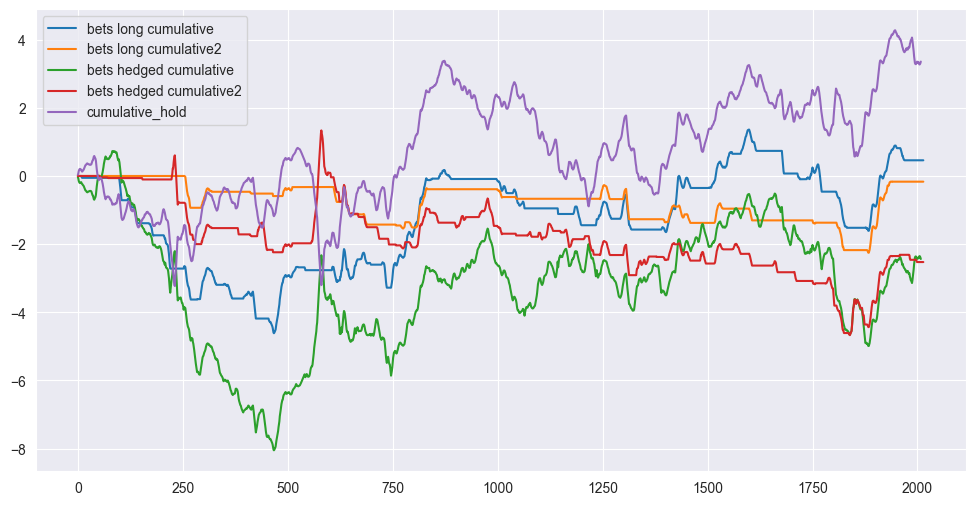

In [44]:
results_df[['bets long cumulative', 'bets long cumulative2', 'bets hedged cumulative', 'bets hedged cumulative2', 'cumulative_hold']].plot(figsize=(12, 6))